In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

In [8]:
df = pd.read_csv("/kaggle/input/-spotify-tracks-dataset/dataset.csv")
print(df.shape)

(114000, 21)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [10]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [11]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [12]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

### Handle missing values (genre-based imputation)

In [13]:
audio_cols = [
    'duration_ms','danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness','valence','tempo'
]


for col in audio_cols:
    if df[col].isnull().any():
        genre_median = df.groupby('track_genre')[col].transform('median')
        df[col] = df[col].fillna(genre_median)
        df[col] = df[col].fillna(df[col].median())

df['artists'] = df['artists'].fillna(df['artists'].mode()[0])
df['album_name'] = df['album_name'].fillna(df['album_name'].mode()[0])
df['track_name'] = df['track_name'].fillna(df['track_name'].mode()[0])

df = df.drop(columns=['Unnamed: 0','track_id','track_name','album_name'])

### Derived Features

In [14]:
df['duration_log'] = np.log1p(df['duration_ms'])
df['energy_dance_ratio'] = df['energy'] / (df['danceability'] + 1e-5)
df['acoustic_electronic'] = df['acousticness'] - df['instrumentalness']

### Outlier Removal

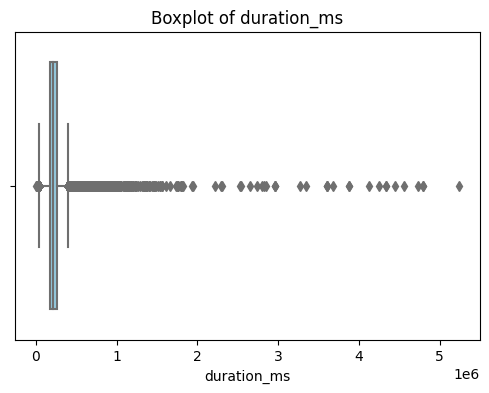

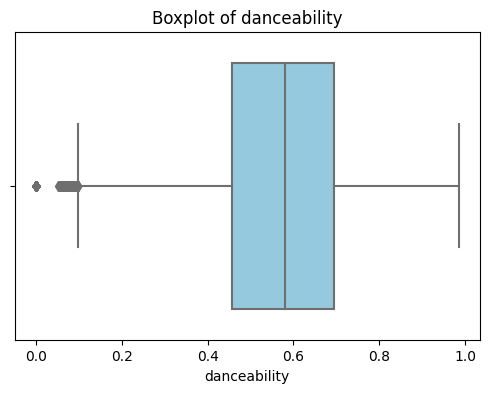

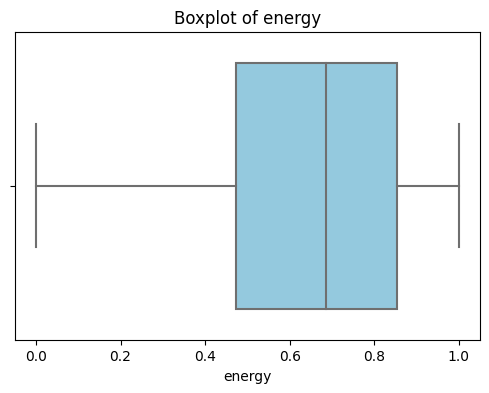

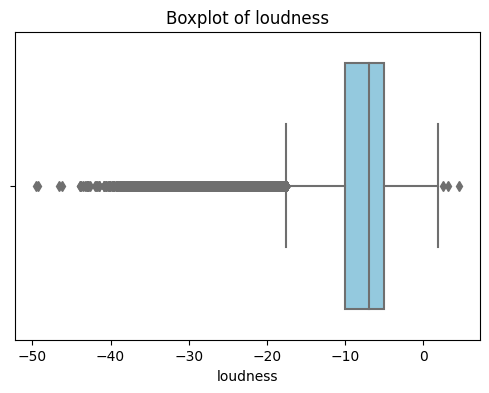

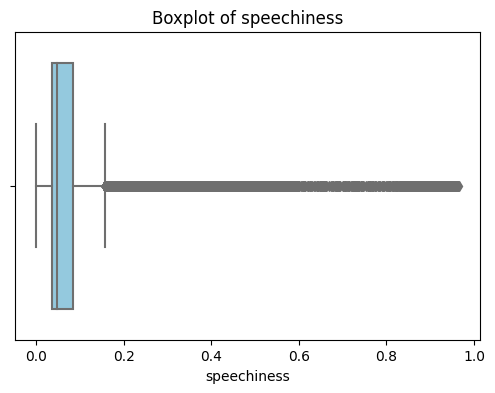

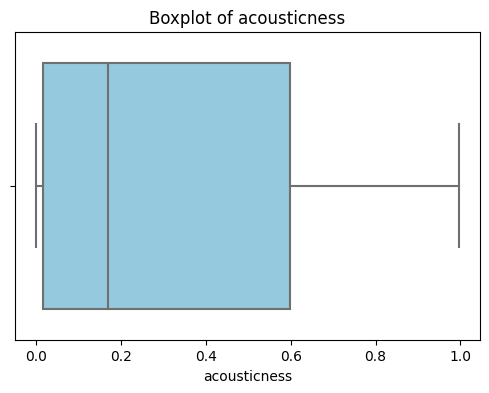

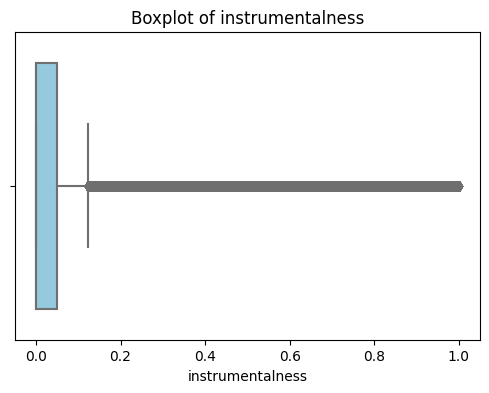

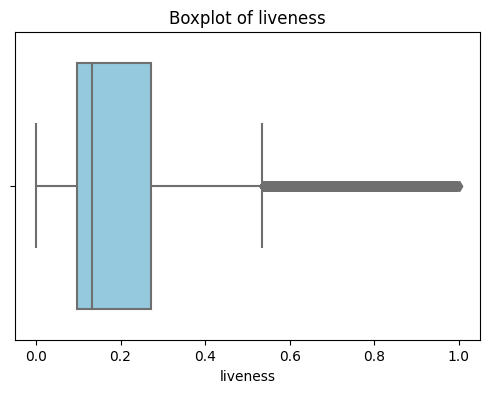

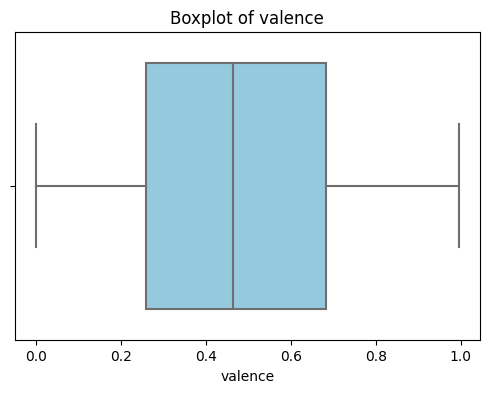

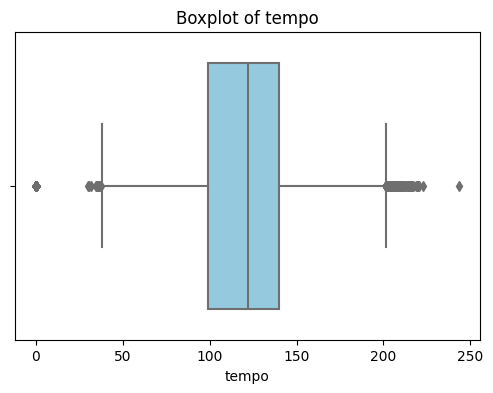

In [15]:
audio_cols = [
    'duration_ms','danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness','valence','tempo'
]

for col in audio_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['tempo','duration_ms','loudness','speechiness','instrumentalness']:
    df = remove_outliers_iqr(df, col)

### Popularity Bias Handling

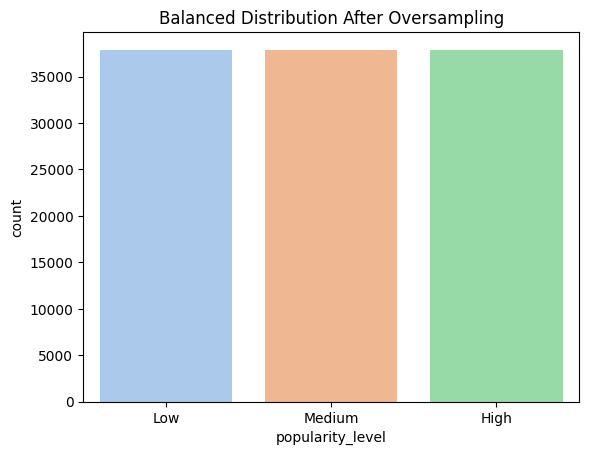

In [17]:
df['popularity_level'] = pd.cut(df['popularity'],
                                bins=[-1,30,70,100],
                                labels=['Low','Medium','High'])

max_count = df['popularity_level'].value_counts().max()
balanced_parts = []
for lvl in ['Low','Medium','High']:
    part = df[df['popularity_level']==lvl]
    if len(part)>0:
        balanced_parts.append(part.sample(n=max_count,replace=True,random_state=42))

oversampled_df = pd.concat(balanced_parts).reset_index(drop=True)

sns.countplot(data=oversampled_df,x='popularity_level',
              order=['Low','Medium','High'],palette='pastel')
plt.title("Balanced Distribution After Oversampling")
plt.show()

### Encoding High-Cardinality Variables

In [18]:
# Artist frequency encoding
artist_counts = oversampled_df['artists'].value_counts()
oversampled_df['artist_freq'] = oversampled_df['artists'].map(artist_counts).fillna(1)

y = oversampled_df['popularity']
X = oversampled_df.drop(columns=['popularity','popularity_level','artists'])

# Train/test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,
    stratify=oversampled_df['popularity_level']
)

# One-hot encode genre
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')
ohe.fit(X_train[['track_genre']])

genre_train = ohe.transform(X_train[['track_genre']])
genre_test  = ohe.transform(X_test[['track_genre']])

genre_cols = ohe.get_feature_names_out(['track_genre'])
genre_df_train = pd.DataFrame(genre_train,columns=genre_cols,index=X_train.index)
genre_df_test  = pd.DataFrame(genre_test,columns=genre_cols,index=X_test.index)

X_train = pd.concat([X_train.drop(columns=['track_genre']),genre_df_train],axis=1)
X_test  = pd.concat([X_test.drop(columns=['track_genre']),genre_df_test],axis=1)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

train_data = pd.concat([pd.DataFrame(X_train_scaled,columns=X_train.columns),
                        y_train.reset_index(drop=True)],axis=1)
test_data  = pd.concat([pd.DataFrame(X_test_scaled,columns=X_test.columns),
                        y_test.reset_index(drop=True)],axis=1)

train_data.to_csv("train_data.csv",index=False)
test_data.to_csv("test_data.csv",index=False)

In [19]:
train_data.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness',
       ...
       'track_genre_study', 'track_genre_swedish', 'track_genre_synth-pop',
       'track_genre_tango', 'track_genre_techno', 'track_genre_trance',
       'track_genre_trip-hop', 'track_genre_turkish',
       'track_genre_world-music', 'popularity'],
      dtype='object', length=132)

## Exploratory Data Analysis (EDA)

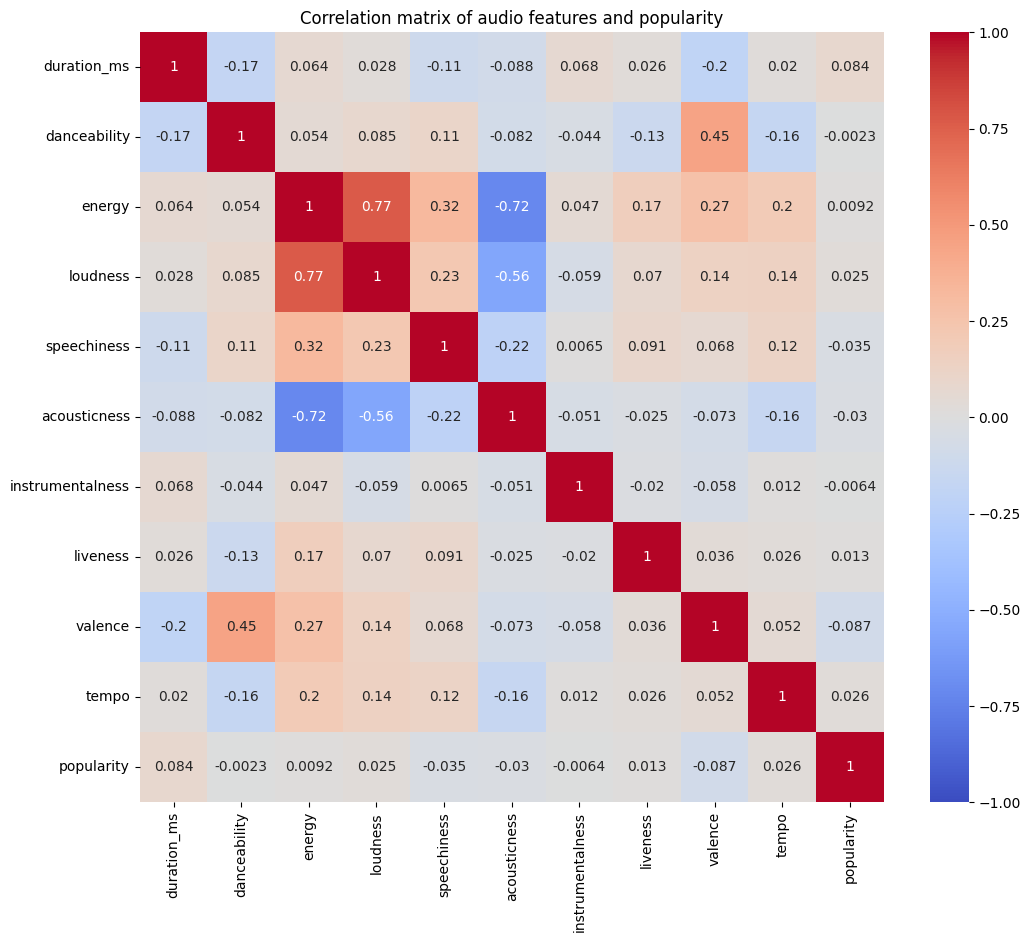

In [20]:
# Correlation matrix
corr = df[audio_cols+['popularity']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr,cmap='coolwarm',center=0,vmin=-1,vmax=1,annot=True)
plt.title("Correlation matrix of audio features and popularity")
plt.show()

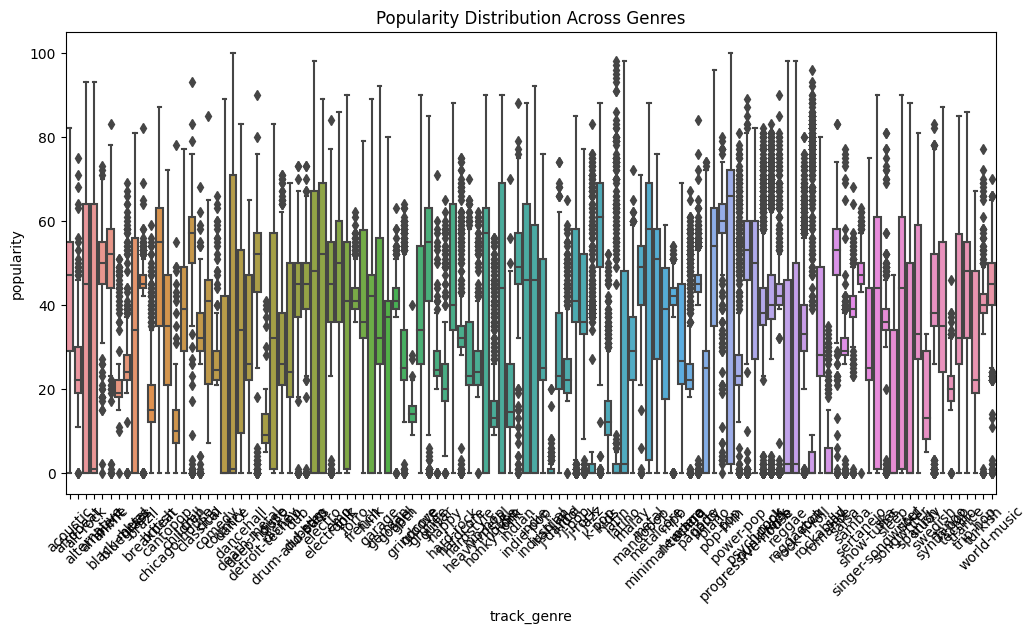

In [21]:
# Popularity distribution across genres
plt.figure(figsize=(12,6))
sns.boxplot(x='track_genre',y='popularity',data=df)
plt.xticks(rotation=45)
plt.title("Popularity Distribution Across Genres")
plt.show()

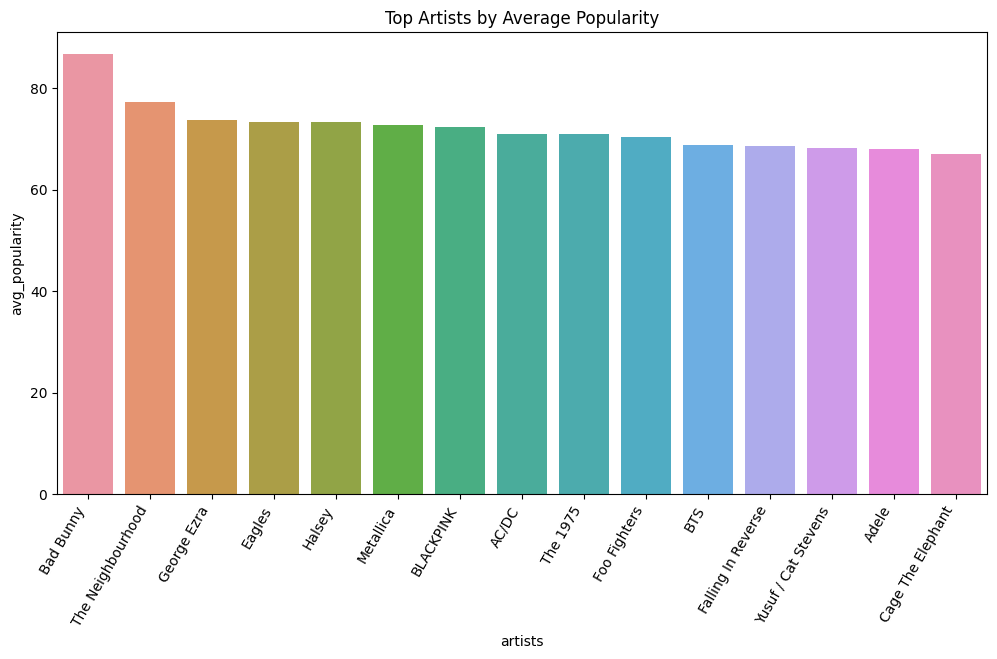

In [22]:
# Artist-level analysis
artist_stats = (
    df.groupby('artists')
      .agg(track_count=('popularity','count'),
           avg_popularity=('popularity','mean'))
      .query('track_count>=20')
      .sort_values('avg_popularity',ascending=False)
)

top_artists = artist_stats.head(15).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=top_artists,x='artists',y='avg_popularity')
plt.xticks(rotation=60,ha='right')
plt.title("Top Artists by Average Popularity")
plt.show()

In [23]:
print(train_data.dtypes)

duration_ms                float64
explicit                   float64
danceability               float64
energy                     float64
key                        float64
                            ...   
track_genre_trance         float64
track_genre_trip-hop       float64
track_genre_turkish        float64
track_genre_world-music    float64
popularity                   int64
Length: 132, dtype: object
